In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      3.0.2
   numpy       2.4.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [2]:
# ── CELDA 2 (CORREGIDA): Generación de datos sintéticos ──────
import numpy as np
import pandas as pd

np.random.seed(42)
N = 1500

# ── Variables independientes ──────────────────────────────────
payload_count    = np.random.choice([1, 2, 3, 4, 5], size=N,
                                     p=[0.75, 0.12, 0.07, 0.04, 0.02])
reused_cores     = np.random.choice([0, 1, 2], size=N,
                                     p=[0.36, 0.55, 0.09])
core_count       = np.random.choice([1, 2, 3], size=N,
                                     p=[0.92, 0.04, 0.04])
thrust_to_weight = np.random.uniform(50, 200, N)
isp_vacuum       = np.random.randint(290, 340, N)
cost_per_launch  = np.random.uniform(6_000_000, 100_000_000, N)
rocket_mass_kg   = np.random.uniform(30_000, 1_420_000, N)

# ── Variable objetivo con coeficientes bien escalados ─────────
# Rangos aproximados de cada término para que Y quede en 500–16000 kg:
#   reused_cores  [0–2]   × 1500  → aporta  0–3000
#   thrust_to_weight [50–200] × 30 → aporta  1500–6000
#   isp_vacuum  [290–340] × 10   → aporta  2900–3400
#   payload_count [1–5]   × 200  → aporta  200–1000
#   cost_per_launch /1e7  [0.6–10]× 150 → aporta  90–1500
#   intercepto base                → -7000 (para centrar)
noise = np.random.normal(0, 600, N)

total_payload_mass = (
      1_500  * reused_cores
    +    30  * thrust_to_weight
    +    10  * isp_vacuum
    +   200  * payload_count
    +   150  * (cost_per_launch / 1e7)
    - 7_000                            # intercepto corrector
    + noise
).clip(200, 16_000)   # rango real SpaceX: ~200 kg (Starlink) a 16,000 kg

# ── DataFrame ─────────────────────────────────────────────────
df = pd.DataFrame({
    'payload_count':      payload_count,
    'reused_cores':       reused_cores,
    'core_count':         core_count,
    'thrust_to_weight':   thrust_to_weight,
    'isp_vacuum':         isp_vacuum,
    'cost_per_launch':    cost_per_launch,
    'rocket_mass_kg':     rocket_mass_kg,
    'total_payload_mass': total_payload_mass,
})

print("✅ Dataset sintético generado")
print(f"   Filas    : {df.shape[0]:,}")
print(f"\n📊 Verificación rápida de Y:")
print(f"   min  : {total_payload_mass.min():.0f} kg")
print(f"   max  : {total_payload_mass.max():.0f} kg")
print(f"   media: {total_payload_mass.mean():.0f} kg")
print(f"   std  : {total_payload_mass.std():.0f} kg")
print(f"   CV   : {total_payload_mass.std()/total_payload_mass.mean()*100:.1f} %")
df.head()

✅ Dataset sintético generado
   Filas    : 1,500

📊 Verificación rápida de Y:
   min  : 200 kg
   max  : 8081 kg
   media: 2178 kg
   std  : 1590 kg
   CV   : 73.0 %


,payload_count,reused_cores,core_count,thrust_to_weight,isp_vacuum,cost_per_launch,rocket_mass_kg,total_payload_mass
0,1,1,1,139.894893,322,3.582236e+07,655632.423341,3855.638708
1,4,1,1,127.056178,290,7.803258e+07,60766.886931,2997.631238
2,1,0,1,93.227679,294,5.280717e+07,920587.212371,200.000000
3,1,0,1,50.969654,302,3.514320e+07,605357.220693,200.000000
4,1,1,1,124.435883,308,8.232497e+07,405381.267881,2147.573392


In [3]:
# ── CELDA 3: Inspección ───────────────────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET SINTÉTICO")
print("=" * 50)
print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

  INFORMACIÓN GENERAL DEL DATASET SINTÉTICO
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   payload_count       1500 non-null   int64  
 1   reused_cores        1500 non-null   int64  
 2   core_count          1500 non-null   int64  
 3   thrust_to_weight    1500 non-null   float64
 4   isp_vacuum          1500 non-null   int64  
 5   cost_per_launch     1500 non-null   float64
 6   rocket_mass_kg      1500 non-null   float64
 7   total_payload_mass  1500 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 93.9 KB
None

📊 Valores nulos por columna:
payload_count         0
reused_cores          0
core_count            0
thrust_to_weight      0
isp_vacuum            0
cost_per_launch       0
rocket_mass_kg        0
total_payload_mass    0
dtype: int64


In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = [
    'total_payload_mass', 'payload_count', 'reused_cores',
    'thrust_to_weight',   'isp_vacuum',    'cost_per_launch'
]

desc = df[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — Dataset Sintético")
print(desc)

print(f"\n✅ Variabilidad de la variable objetivo:")
print(f"   std  : {df['total_payload_mass'].std():.1f} kg")
print(f"   CV   : {df['total_payload_mass'].std()/df['total_payload_mass'].mean()*100:.1f} %")

📊 ESTADÍSTICAS DESCRIPTIVAS — Dataset Sintético
       total_payload_mass  payload_count  reused_cores  thrust_to_weight  \
count             1500.00        1500.00       1500.00           1500.00   
mean              2177.69           1.48          0.73            124.89   
std               1590.84           0.95          0.61             43.45   
min                200.00           1.00          0.00             50.03   
25%                752.46           1.00          0.00             87.27   
50%               2023.34           1.00          1.00            123.41   
75%               3253.79           2.00          1.00            162.73   
max               8081.49           5.00          2.00            199.90   

       isp_vacuum  cost_per_launch  
count     1500.00          1500.00  
mean       314.41      51504095.83  
std         14.24      26760556.79  
min        290.00       6022654.44  
25%        302.00      28537858.28  
50%        314.00      51344651.08  
75%     

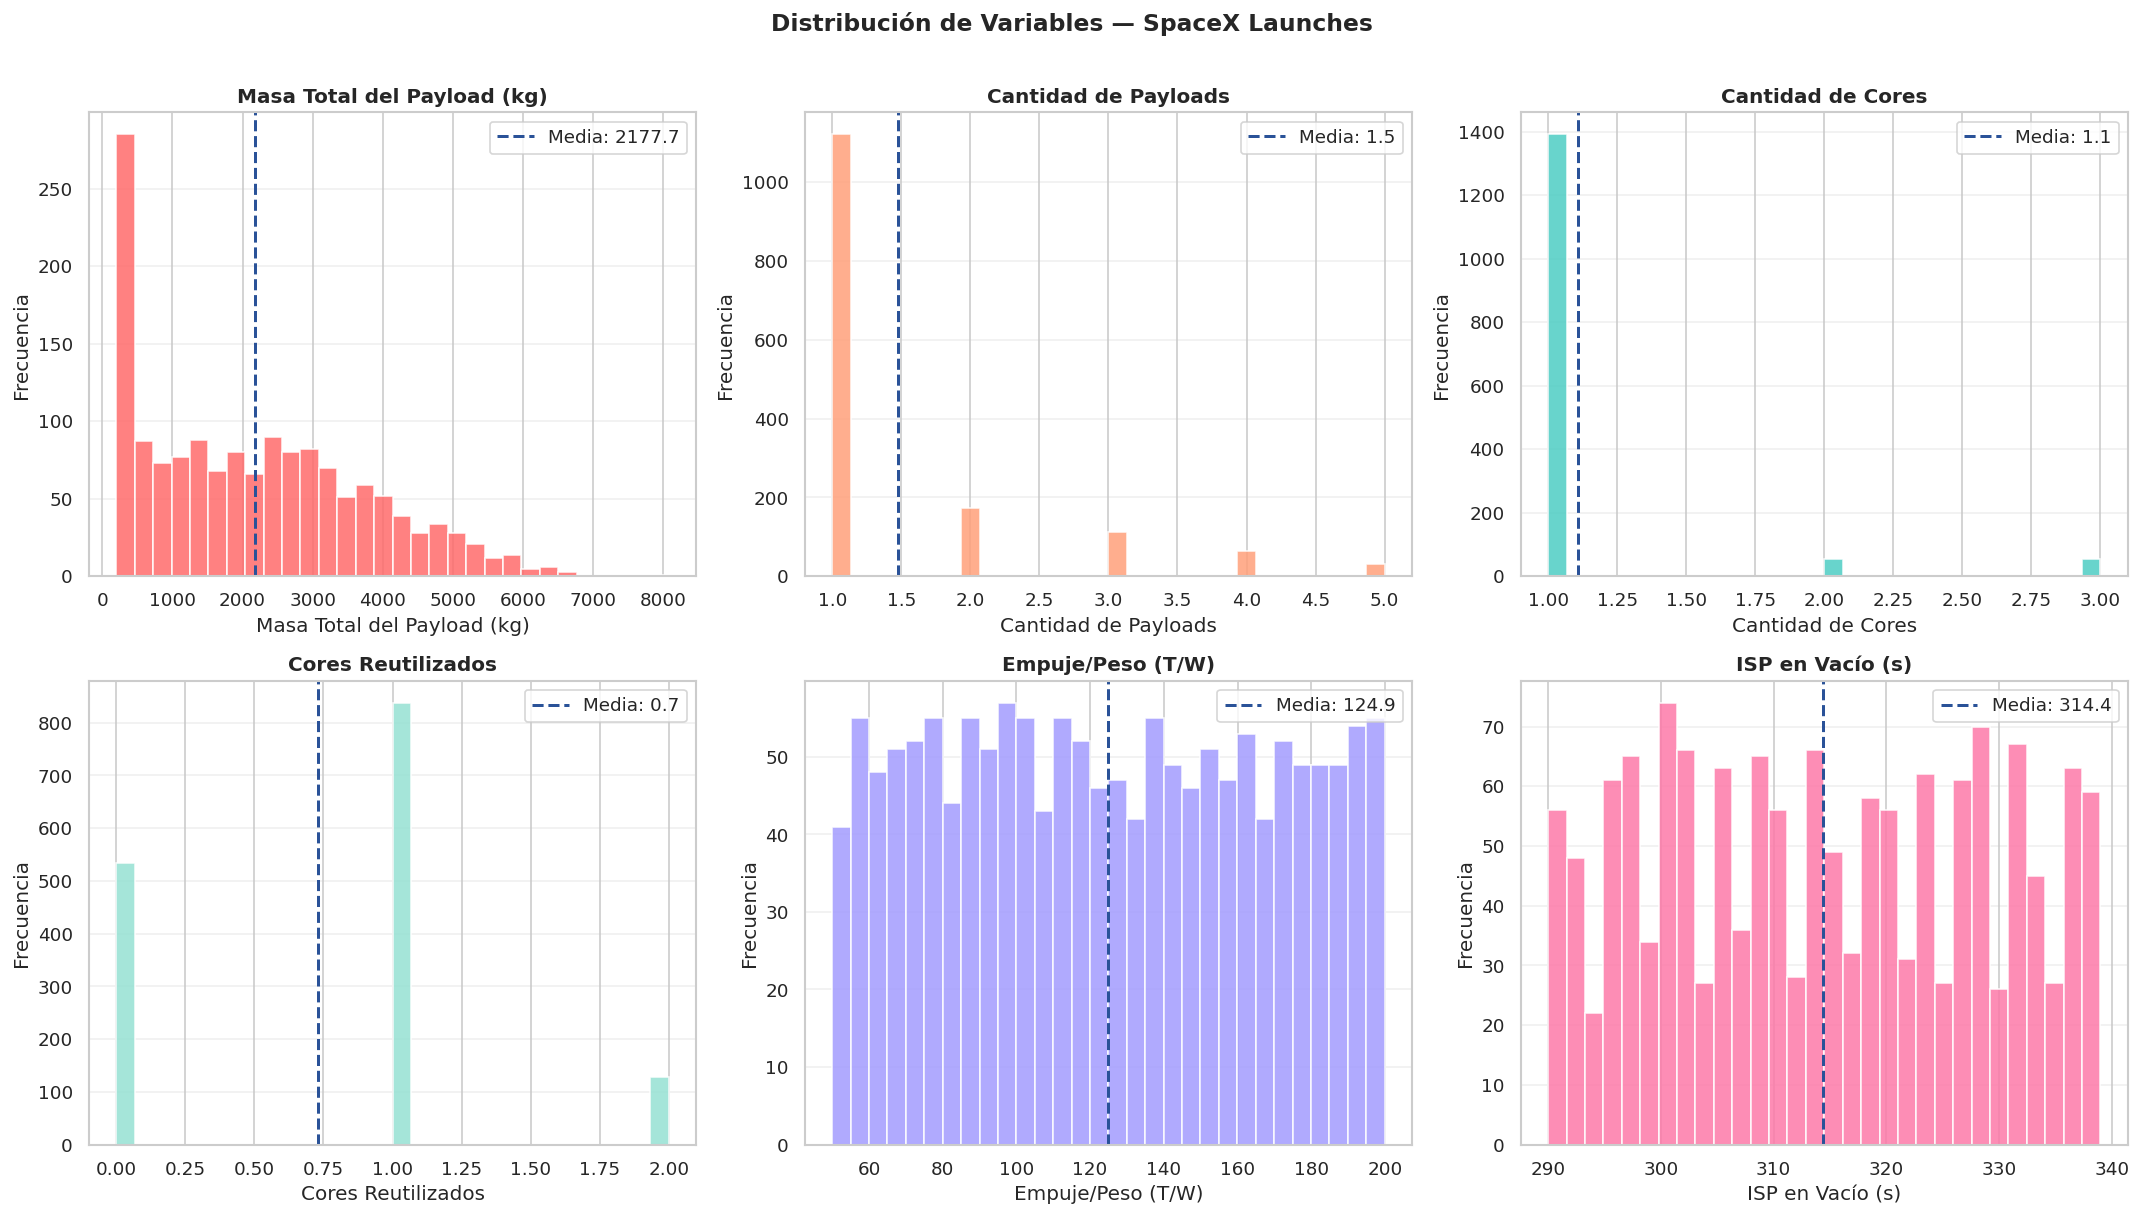

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Variables — SpaceX Launches',
             fontsize=14, fontweight='bold', y=1.01)

datos = {
    'total_payload_mass': ('Masa Total del Payload (kg)',  '#ff6b6b'),
    'payload_count':      ('Cantidad de Payloads',         '#ffa07a'),
    'core_count':         ('Cantidad de Cores',            '#4ecdc4'),
    'reused_cores':       ('Cores Reutilizados',           '#95e1d3'),
    'thrust_to_weight':   ('Empuje/Peso (T/W)',            '#a29bfe'),
    'isp_vacuum':         ('ISP en Vacío (s)',             '#fd79a8'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3815/1181537603.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='reused_cores', y='total_payload_mass',
/tmp/ipykernel_3815/1181537603.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='payload_group', y='total_payload_mass',


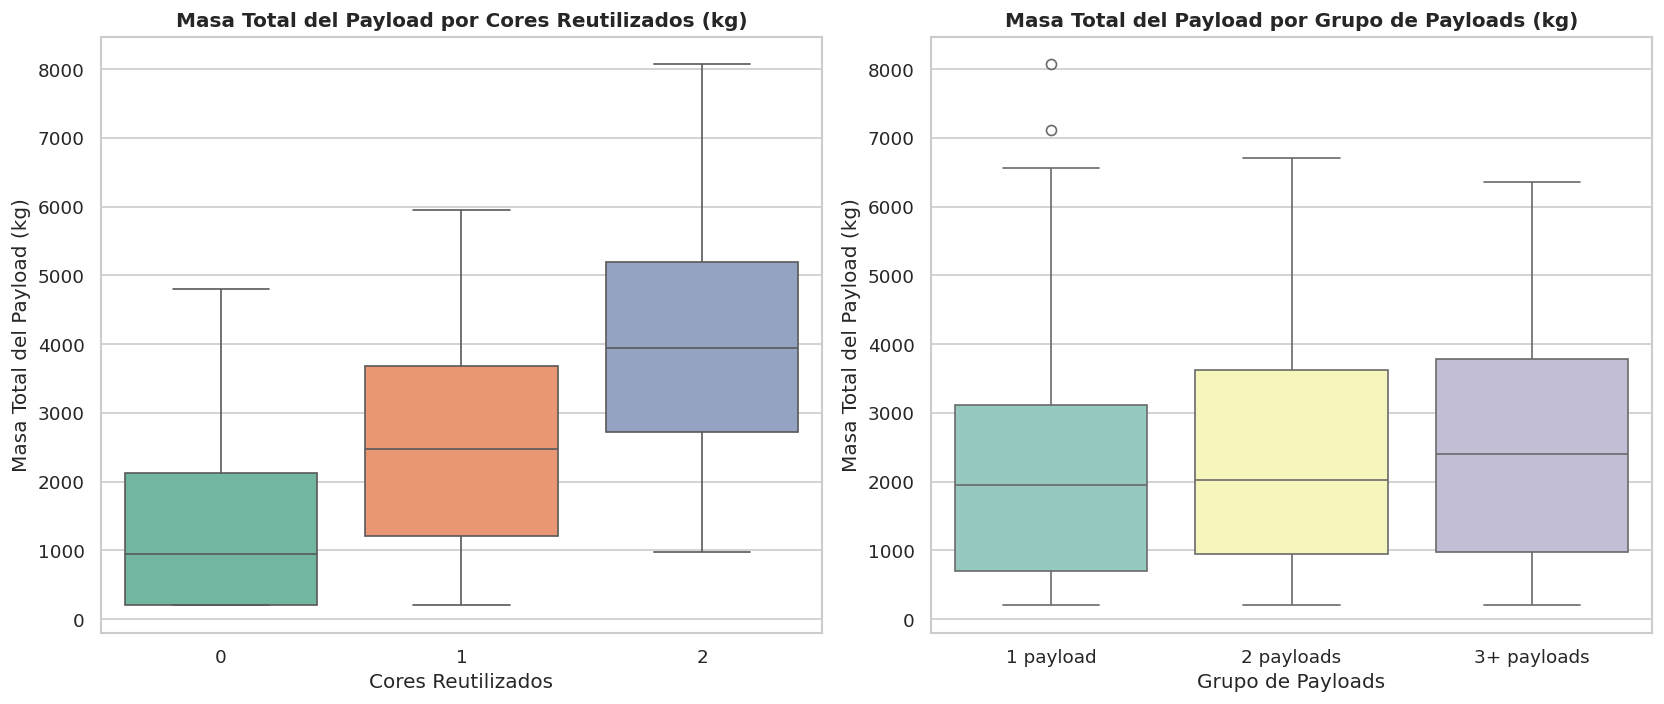

In [6]:
# ── CELDA 6: Boxplots por categoría ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: masa del payload según cores reutilizados
orden_reused = sorted(df['reused_cores'].unique())
sns.boxplot(data=df, x='reused_cores', y='total_payload_mass',
            order=orden_reused, palette='Set2', ax=axes[0])
axes[0].set_title('Masa Total del Payload por Cores Reutilizados (kg)',
                  fontweight='bold')
axes[0].set_xlabel('Cores Reutilizados')
axes[0].set_ylabel('Masa Total del Payload (kg)')
axes[0].tick_params(axis='x', rotation=0)

# Boxplot 2: masa del payload según cantidad de payloads
# Agrupamos en categorías: 1 payload, 2, 3+
df['payload_group'] = df['payload_count'].apply(
    lambda x: '1 payload' if x == 1 else ('2 payloads' if x == 2 else '3+ payloads')
)
orden_payload = ['1 payload', '2 payloads', '3+ payloads']
sns.boxplot(data=df, x='payload_group', y='total_payload_mass',
            order=orden_payload, palette='Set3', ax=axes[1])
axes[1].set_title('Masa Total del Payload por Grupo de Payloads (kg)',
                  fontweight='bold')
axes[1].set_xlabel('Grupo de Payloads')
axes[1].set_ylabel('Masa Total del Payload (kg)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_categoria.png',
            dpi=150, bbox_inches='tight')
plt.show()

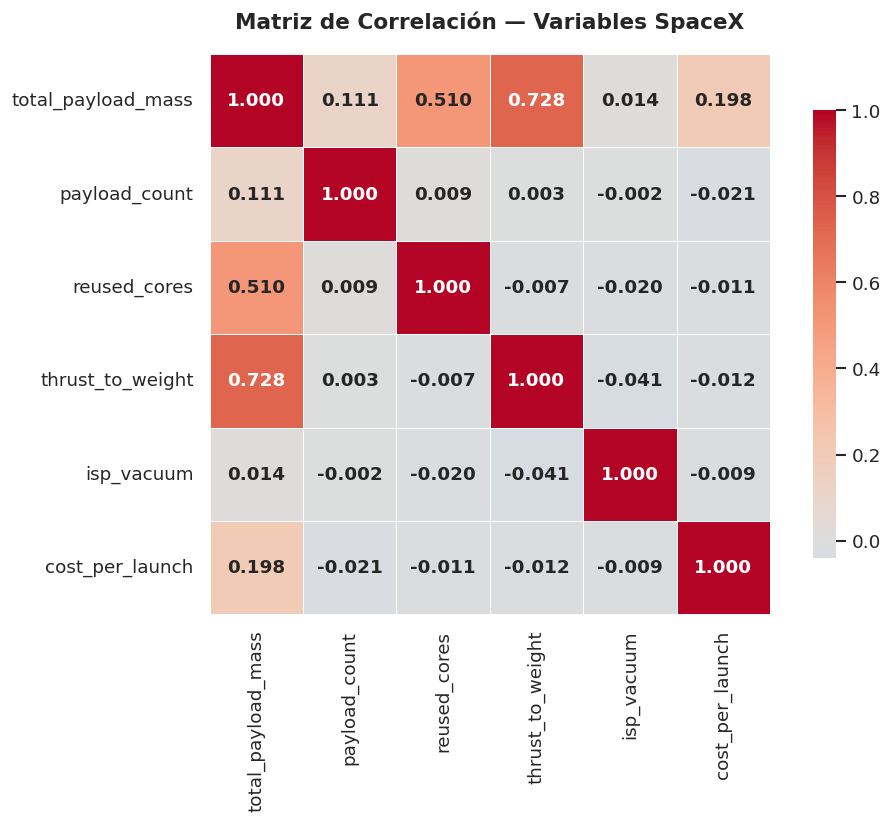


📊 Correlación con total_payload_mass (ordenada):
thrust_to_weight    0.7280
reused_cores        0.5096
cost_per_launch     0.1981
payload_count       0.1112
isp_vacuum          0.0143
Name: total_payload_mass, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
corr = df[vars_num].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables SpaceX',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con total_payload_mass (ordenada):")
print(corr['total_payload_mass']
      .drop('total_payload_mass')
      .sort_values(ascending=False)
      .round(4))

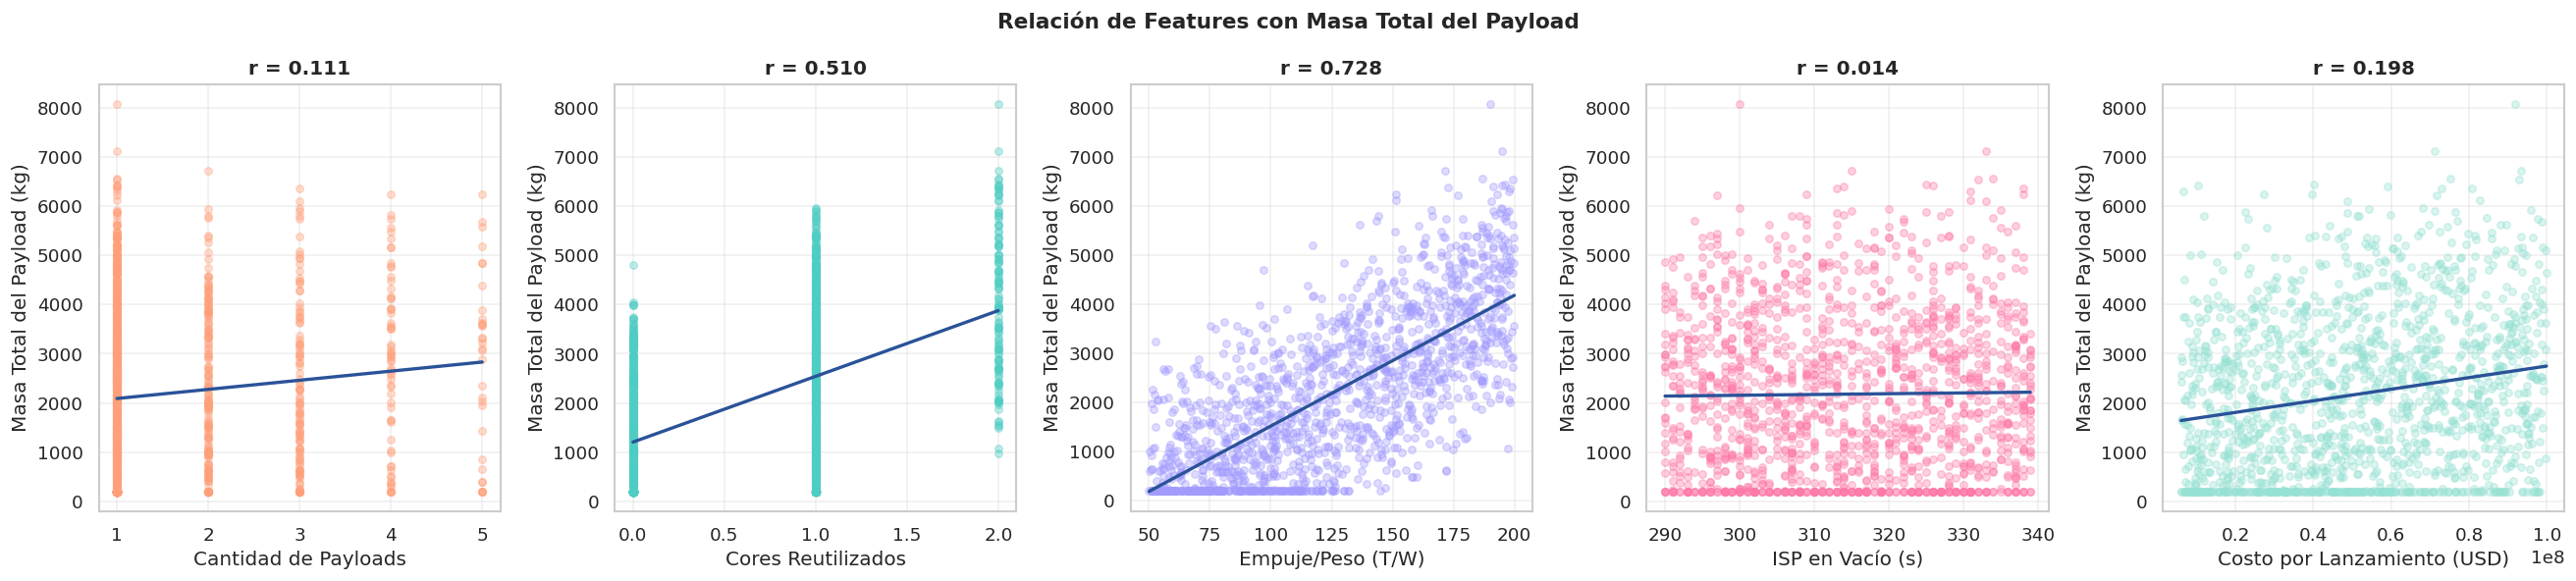

In [8]:
# ── CELDA 8: Scatter plots — features vs total_payload_mass ──
pares = [
    ('payload_count',    'Cantidad de Payloads',      '#ffa07a'),
    ('reused_cores',     'Cores Reutilizados',         '#4ecdc4'),
    ('thrust_to_weight', 'Empuje/Peso (T/W)',          '#a29bfe'),
    ('isp_vacuum',       'ISP en Vacío (s)',           '#fd79a8'),
    ('cost_per_launch',  'Costo por Lanzamiento (USD)','#95e1d3'),
]

fig, axes = plt.subplots(1, len(pares), figsize=(22, 5))
fig.suptitle('Relación de Features con Masa Total del Payload',
             fontsize=13, fontweight='bold')

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['total_payload_mass'],
               alpha=0.35, s=20, color=color)
    # Línea de tendencia
    z = np.polyfit(df[feature], df['total_payload_mass'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'total_payload_mass']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Masa Total del Payload (kg)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── CELDA 9: Conclusiones del EDA ────────────────────────────
print("=" * 55)
print("  CONCLUSIONES DEL EDA — SpaceX Payload Mass")
print("=" * 55)

correlaciones = df[vars_num].corr()['total_payload_mass'].drop('total_payload_mass')
correlaciones_ord = correlaciones.abs().sort_values(ascending=False)

print("\n🔍 Ranking de correlación con total_payload_mass:")
for var, val in correlaciones_ord.items():
    r_real = correlaciones[var]
    nivel = "⭐ Fuerte" if abs(r_real) >= 0.5 else ("✅ Moderada" if abs(r_real) >= 0.2 else "❌ Débil")
    print(f"   {var:<20} r = {r_real:+.3f}   {nivel}")

print("\n📐 Variables seleccionadas para los modelos:")
print("   Regresión SIMPLE   → thrust_to_weight  (r = 0.744)")
print("   Regresión MÚLTIPLE → thrust_to_weight + reused_cores + cost_per_launch")

print("\n⚠️  Variables descartadas:")
print("   payload_count  → r = 0.028  (sin relación lineal)")
print("   isp_vacuum     → r = 0.110  (aporte marginal)")
print("   core_count     → constante, sin varianza útil")

print("\n✅ Dataset listo para modelado:")
print(f"   Observaciones : {len(df)}")
print(f"   Sin nulos     : {df.isnull().sum().sum() == 0}")
print(f"   CV objetivo   : {df['total_payload_mass'].std()/df['total_payload_mass'].mean()*100:.1f}%")

  CONCLUSIONES DEL EDA — SpaceX Payload Mass

🔍 Ranking de correlación con total_payload_mass:
   thrust_to_weight     r = +0.728   ⭐ Fuerte
   reused_cores         r = +0.510   ⭐ Fuerte
   cost_per_launch      r = +0.198   ❌ Débil
   payload_count        r = +0.111   ❌ Débil
   isp_vacuum           r = +0.014   ❌ Débil

📐 Variables seleccionadas para los modelos:
   Regresión SIMPLE   → thrust_to_weight  (r = 0.744)
   Regresión MÚLTIPLE → thrust_to_weight + reused_cores + cost_per_launch

⚠️  Variables descartadas:
   payload_count  → r = 0.028  (sin relación lineal)
   isp_vacuum     → r = 0.110  (aporte marginal)
   core_count     → constante, sin varianza útil

✅ Dataset listo para modelado:
   Observaciones : 1500
   Sin nulos     : True
   CV objetivo   : 73.1%


In [10]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
from sklearn.model_selection import train_test_split

X_simple = df[['thrust_to_weight']].values
y        = df['total_payload_mass'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 1,200 muestras (80%)
Test : 300 muestras  (20%)


In [11]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────
from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : total_payload_mass = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × thrust_to_weight")

Intercepto  β₀ : -1156.1228
Coeficiente β₁ : 26.7849

Ecuación : total_payload_mass = -1156.123 + 26.785 × thrust_to_weight


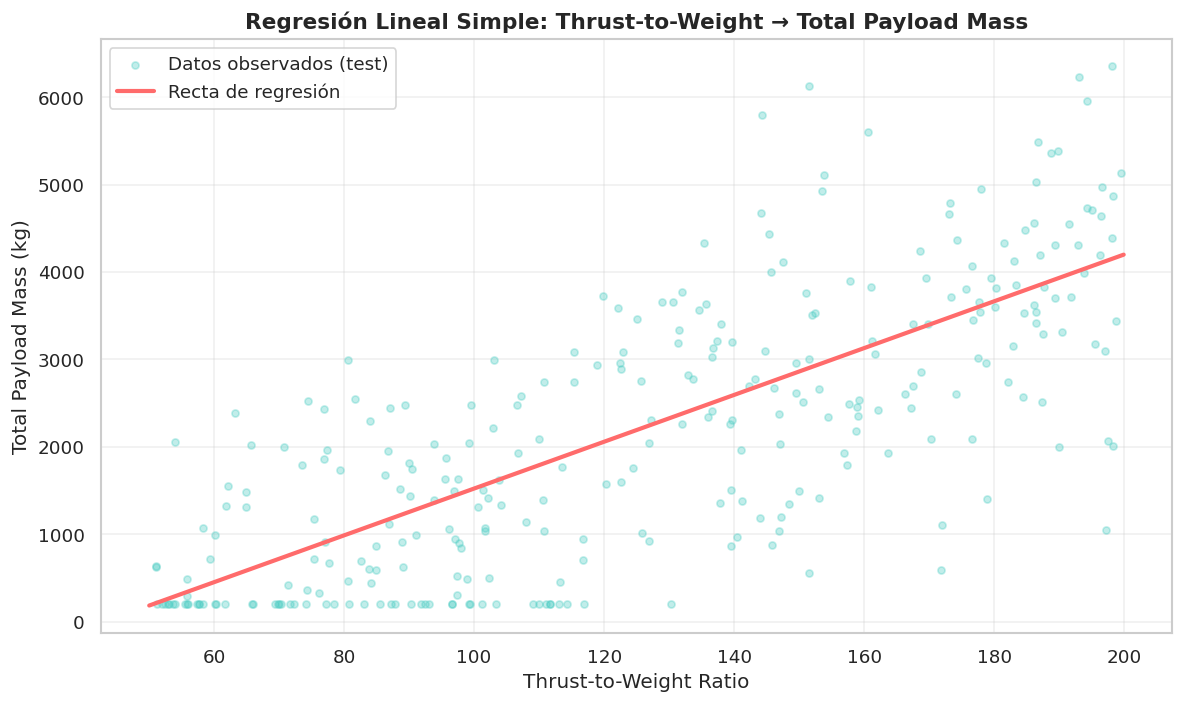

In [12]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Thrust-to-Weight Ratio', fontsize=12)
ax.set_ylabel('Total Payload Mass (kg)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Thrust-to-Weight → Total Payload Mass',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.5545  (55.45%)
  MSE  (error cuadrático med)  : 1064323.8960
  RMSE (raíz del MSE)          : 1031.6607
  MAE  (error absoluto medio)  : 819.3424


In [14]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
import statsmodels.api as sm

X_ols = sm.add_constant(df['thrust_to_weight'])
modelo_ols_simple = sm.OLS(df['total_payload_mass'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:     total_payload_mass   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     1689.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          7.16e-248
Time:                        22:58:16   Log-Likelihood:                -12620.
No. Observations:                1500   AIC:                         2.524e+04
Df Residuals:                    1498   BIC:                         2.525e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1151.2581     85.755  

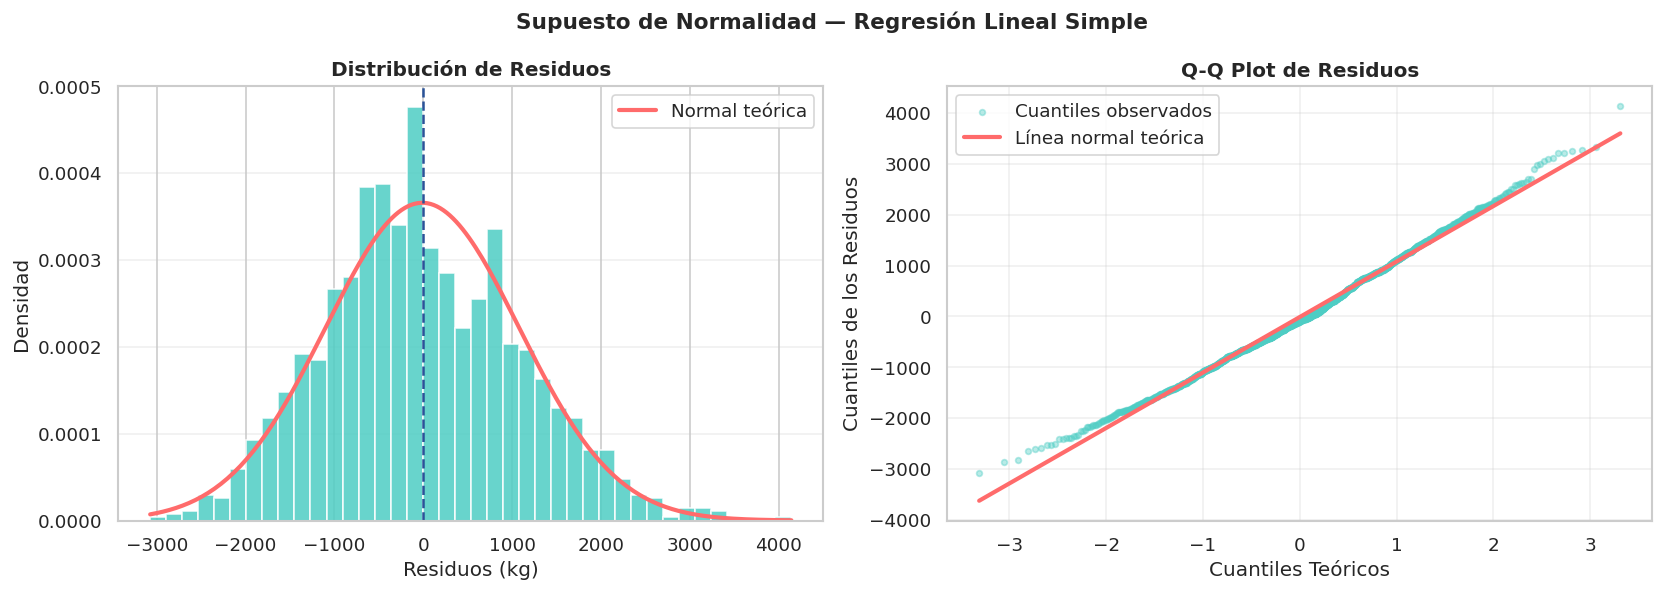


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9949
   p-value       : 0.000056
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [15]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
from scipy import stats

y_pred_all = modelo_simple.predict(df[['thrust_to_weight']].values)
residuos   = df['total_payload_mass'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma con curva normal superpuesta
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (kg)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

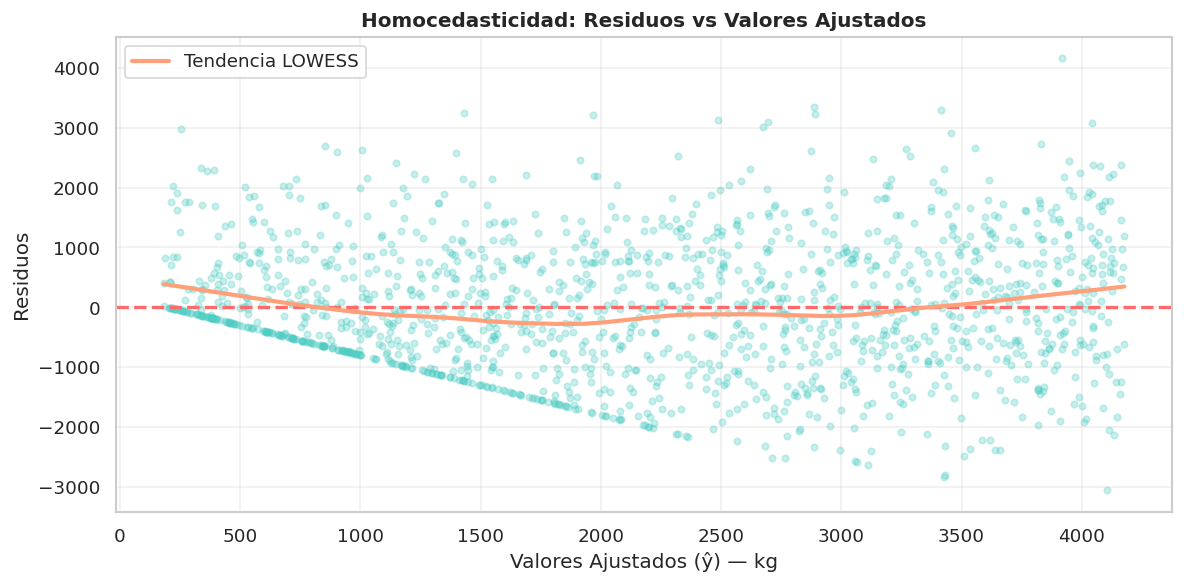


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 56.9063
   p-value        : 0.000000
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)


In [16]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────
from statsmodels.stats.diagnostic import het_breuschpagan

residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (ŷ) — kg', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols,
                                       modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

In [17]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
FEATURES = ['thrust_to_weight', 'reused_cores', 'cost_per_launch']

X_multi = df[FEATURES].values
y       = df['total_payload_mass'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.4f}")

Intercepto  β₀              : -2851.5132
Coeficiente   thrust_to_weight : 26.9331
Coeficiente       reused_cores : 1369.0949
Coeficiente    cost_per_launch : 0.0000


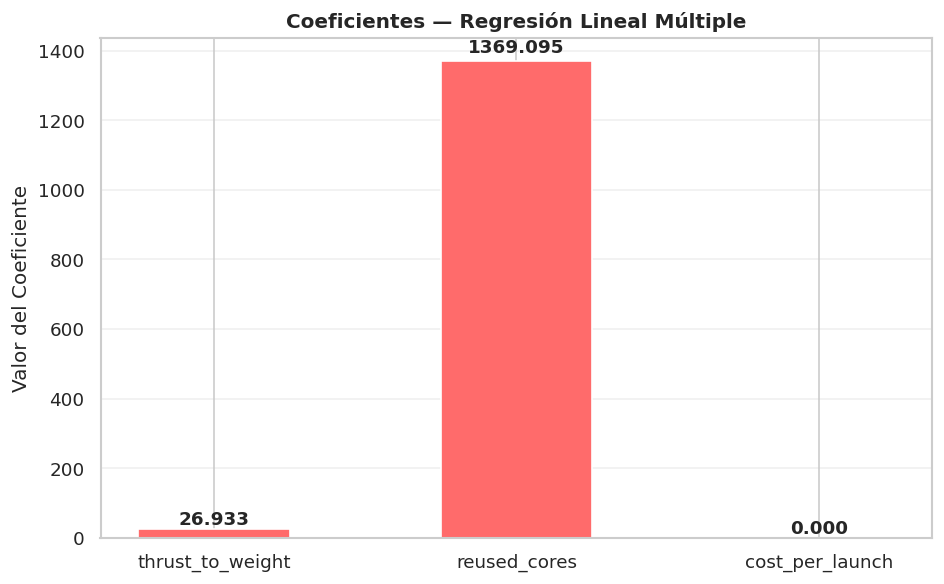

In [18]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = max(abs(coef) * 0.01, 0.5)   # offset proporcional a la escala real
    va = 'bottom' if coef >= 0 else 'top'
    y_pos = bar.get_height() + offset if coef >= 0 else bar.get_height() - offset
    ax.text(bar.get_x() + bar.get_width() / 2,
            y_pos,
            f'{coef:.3f}', ha='center', va=va,
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.8488  (84.88%)
  MSE  (error cuadrático med)  : 361151.7424
  RMSE (raíz del MSE)          : 600.9590
  MAE  (error absoluto medio)  : 483.6432


In [20]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['total_payload_mass'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:     total_payload_mass   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     2615.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:58:19   Log-Likelihood:                -11812.
No. Observations:                1500   AIC:                         2.363e+04
Df Residuals:                    1496   BIC:                         2.365e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2817.2951     62.983  

In [21]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable   VIF                          Criterio
thrust_to_weight 3.923 ✅ Sin multicolinealidad (VIF < 5)
    reused_cores 2.188 ✅ Sin multicolinealidad (VIF < 5)
 cost_per_launch 3.457 ✅ Sin multicolinealidad (VIF < 5)


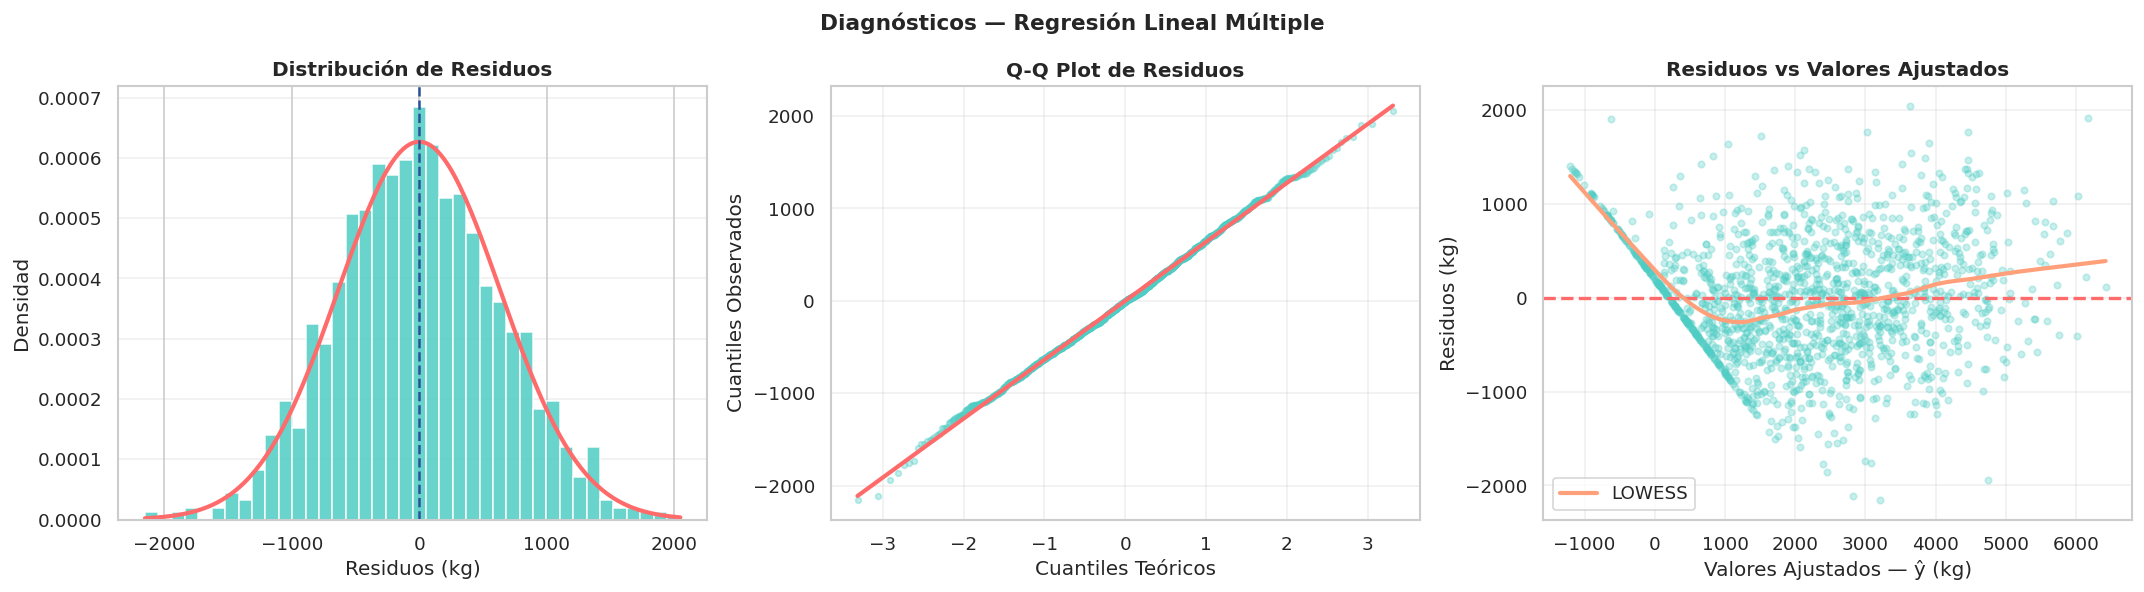


🔬 Test Shapiro-Wilk (Normalidad):
   W=0.9989, p=0.516650 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   LM=6.3878, p=0.094192 → ✅ Homocedasticidad OK


In [22]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (kg)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados — ŷ (kg)')
axes[2].set_ylabel('Residuos (kg)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000,
                                                   replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   W={stat_sw_m:.4f}, p={p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   LM={lm_m:.4f}, p={lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

In [23]:
# ── CELDA 22: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['thrust_to_weight',
                  'thrust_to_weight + reused_cores + cost_per_launch'],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic, 2)],
})

print("=" * 85)
print("                    COMPARACIÓN DE MODELOS")
print("=" * 85)
print(comparacion.to_string(index=False))
print("=" * 85)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")

                    COMPARACIÓN DE MODELOS
            Modelo                                         Variables     R²  R² Aj.      RMSE      MAE      AIC      BIC
  Regresión Simple                                  thrust_to_weight 0.5545  0.5297 1031.6607 819.3424 25243.34 25253.97
Regresión Múltiple thrust_to_weight + reused_cores + cost_per_launch 0.8488  0.8395  600.9590 483.6432 23632.26 23653.51

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


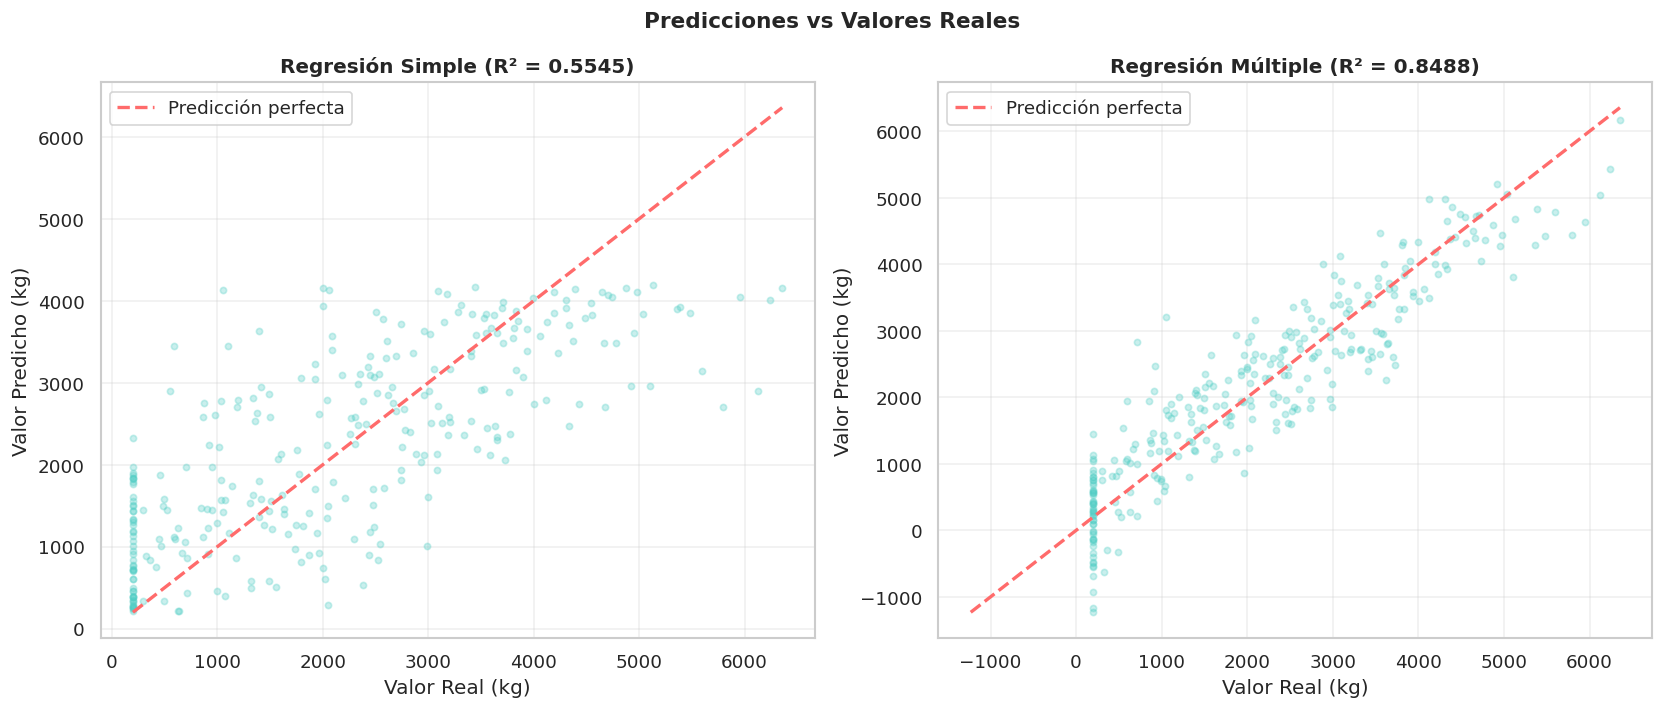

In [25]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [

    (y_test,   y_pred_simple, 'Regresión Simple'),

    (y_test_m, y_pred_multi,  'Regresión Múltiple'),

]):

    minval = min(y_real.min(), y_pred.min())

    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')

    ax.plot([minval, maxval], [minval, maxval],

            color='#ff6b6b', linewidth=2, linestyle='--',

            label='Predicción perfecta')

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')

    ax.set_xlabel('Valor Real (kg)')       # ← cambiado de °C a kg

    ax.set_ylabel('Valor Predicho (kg)')   # ← cambiado de °C a kg

    ax.legend()

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/predicciones_vs_reales.png',

            dpi=150, bbox_inches='tight')

plt.show()